# 01 — EDA: CORINE Olive Grove Distribution

Explore where olives currently grow across **Greece, Italy, Turkey, Spain, and Portugal**
according to CORINE Land Cover 2018 (class 223 — Olive groves).

## Two ways to get the data

| Method | Auth needed? | Coverage | Speed |
|---|---|---|---|
| **Full file download** (Option A) | Free Copernicus account | All of Europe, all classes | ~5 min download, instant queries after |
| **WFS query** (Option B) | None | Any bounding box, class 223 only | ~30 s per country, no local storage |

Run **Option A** once for full analysis; use **Option B** for a quick look without downloading anything.

Cells marked `[mock]` run immediately with no data.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src.utils.visualization import (
    plot_corine_olive_distribution,
    plot_mediterranean_olive_comparison,
    _COUNTRY_NAMES,
)
from src.data.corine import (
    OLIVE_CLASS,
    extract_olive_polygons,
    download_corine,
    download_corine_wfs,
)

RAW_DIR = Path("../data/raw/corine")
TARGET_ISO3 = ["GRC", "ITA", "TUR", "ESP", "PRT"]

---
## Option A — Full file download (recommended)

**One-time setup:**
1. Register free at [land.copernicus.eu](https://land.copernicus.eu) (EU Login)
2. Go to **CORINE Land Cover → CLC 2018 → Download** and select the **GeoPackage** format
3. Right-click the download button → *Copy link address*
4. Add to your `.env` file (project root):
   ```
   CORINE_DOWNLOAD_URL=<paste the URL here>
   ```
5. Run the cell below — it downloads once and caches locally (~1.5 GB ZIP, ~800 MB extracted)

Skip to **Option B** if you haven't registered yet.

In [2]:
import os
import pyproj

# Detect already-extracted GDB — no env var or download needed
_gdb_candidates = list(RAW_DIR.rglob('*.gdb'))
gdb_path = next((p for p in _gdb_candidates if p.is_dir()), None)

if gdb_path:
    print(f'Using local GDB: {gdb_path}')

    _COUNTRY_BBOXES_WGS84 = {
        'GRC': {'west': 20.0, 'south': 34.8, 'east': 29.7, 'north': 41.8},
        'ITA': {'west':  6.6, 'south': 36.6, 'east': 18.5, 'north': 47.1},
        'TUR': {'west': 25.7, 'south': 35.8, 'east': 44.8, 'north': 42.1},
        'ESP': {'west': -9.3, 'south': 35.9, 'east':  4.3, 'north': 43.8},
        'PRT': {'west': -9.5, 'south': 36.8, 'east': -6.2, 'north': 42.2},
    }
    _t = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:3035', always_xy=True)

    olive_by_country = {}
    for iso3, bb in _COUNTRY_BBOXES_WGS84.items():
        minx, miny = _t.transform(bb['west'], bb['south'])
        maxx, maxy = _t.transform(bb['east'], bb['north'])
        gdf = extract_olive_polygons(gdb_path, bbox=(minx, miny, maxx, maxy))
        gdf = gdf.to_crs('EPSG:4326').copy()
        gdf['country'] = iso3
        olive_by_country[iso3] = gdf
        print(f'  {iso3}: {len(gdf):,} olive polygons')

    OPTION = 'A'
else:
    print('Local GDB not found — skip to Option B')
    OPTION = None


Using local GDB: ../data/raw/corine/Results/U2018_CLC2018_V2020_20u1.gdb


  GRC: 3,076 olive polygons


  ITA: 3,782 olive polygons


  TUR: 972 olive polygons


  ESP: 9,427 olive polygons


  PRT: 3,614 olive polygons


---
## Option B — WFS query (no account needed)

Queries the [EEA ArcGIS REST service](https://image.discomap.eea.europa.eu/arcgis/rest/services/Corine/CLC2018_WM/MapServer)
for class-223 polygons within each country's bounding box. No login required.

Caches results to `data/raw/corine/<ISO3>_olives.geojson` so subsequent runs are instant.

**Skip this cell if you already ran Option A.**

In [3]:
if OPTION != "A":
    # Approximate bounding boxes for the olive belt of each country (WGS-84)
    COUNTRY_BBOXES = {
        "GRC": {"west": 20.0, "south": 34.8, "east": 29.7, "north": 41.8},
        "ITA": {"west":  6.6, "south": 36.6, "east": 18.5, "north": 47.1},
        "TUR": {"west": 25.7, "south": 35.8, "east": 44.8, "north": 42.1},
        "ESP": {"west": -9.3, "south": 35.9, "east":  4.3, "north": 43.8},
        "PRT": {"west": -9.5, "south": 36.8, "east": -6.2, "north": 42.2},
    }

    gdfs = {}
    for iso3, bbox in COUNTRY_BBOXES.items():
        cache = RAW_DIR / f"{iso3}_olives.geojson"
        if cache.exists():
            print(f"{iso3}: loading from cache")
            gdfs[iso3] = gpd.read_file(cache)
        else:
            print(f"{iso3}: querying WFS…")
            path = download_corine_wfs(bbox, cache)
            gdfs[iso3] = gpd.read_file(path)
        print(f"  {len(gdfs[iso3]):,} polygons")

    # Merge into a single GeoDataFrame with a country column
    frames = []
    for iso3, gdf in gdfs.items():
        gdf = gdf.copy()
        gdf["country"] = iso3
        frames.append(gdf)
    olive_gdf = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs="EPSG:4326")
    OPTION = "B"
    print(f"\nTotal: {len(olive_gdf):,} polygons across {len(gdfs)} countries")

---
## Mock fallback `[mock]`

If neither Option A nor B has run, generate a tiny stand-in dataset so all
visualizations below still render.

In [4]:
if OPTION is None:
    print('Using mock dataset (one bounding-box polygon per country)')
    from shapely.geometry import box
    mock_polys = {
        'GRC': box(21.5, 36.5, 26.0, 41.0),
        'ITA': box(12.0, 37.5, 16.5, 41.5),
        'TUR': box(26.5, 36.5, 30.0, 39.0),
        'ESP': box(-5.5, 36.5, -1.0, 40.5),
        'PRT': box(-8.5, 37.0, -6.5, 40.0),
    }
    olive_gdf = gpd.GeoDataFrame(
        [{'Code_18': 223, 'country': iso3, 'geometry': geom}
         for iso3, geom in mock_polys.items()],
        crs='EPSG:4326',
    )
    OPTION = 'mock'

if OPTION == 'A':
    total = sum(len(v) for v in olive_by_country.values())
    print(f'Data source: {OPTION} | {total:,} polygons across {len(olive_by_country)} countries')
else:
    print(f'Data source: {OPTION} | {len(olive_gdf):,} polygons')


Data source: A | 20,871 polygons across 5 countries


---
## 1. Build per-country GeoDataFrames

Option A data has no country column — spatial-join against Natural Earth to assign one.
Options B and mock already have `country` set.

In [5]:
if OPTION in ('B', 'mock'):
    country_col = 'country'
    olive_by_country = {
        iso3: olive_gdf[olive_gdf[country_col] == iso3].copy()
        for iso3 in TARGET_ISO3
        if iso3 in olive_gdf[country_col].values
    }
# Option A already built olive_by_country directly

print(f'Countries ready: {list(olive_by_country.keys())}')


Countries ready: ['GRC', 'ITA', 'TUR', 'ESP', 'PRT']


---
## 2. Quick sanity check — Greece only

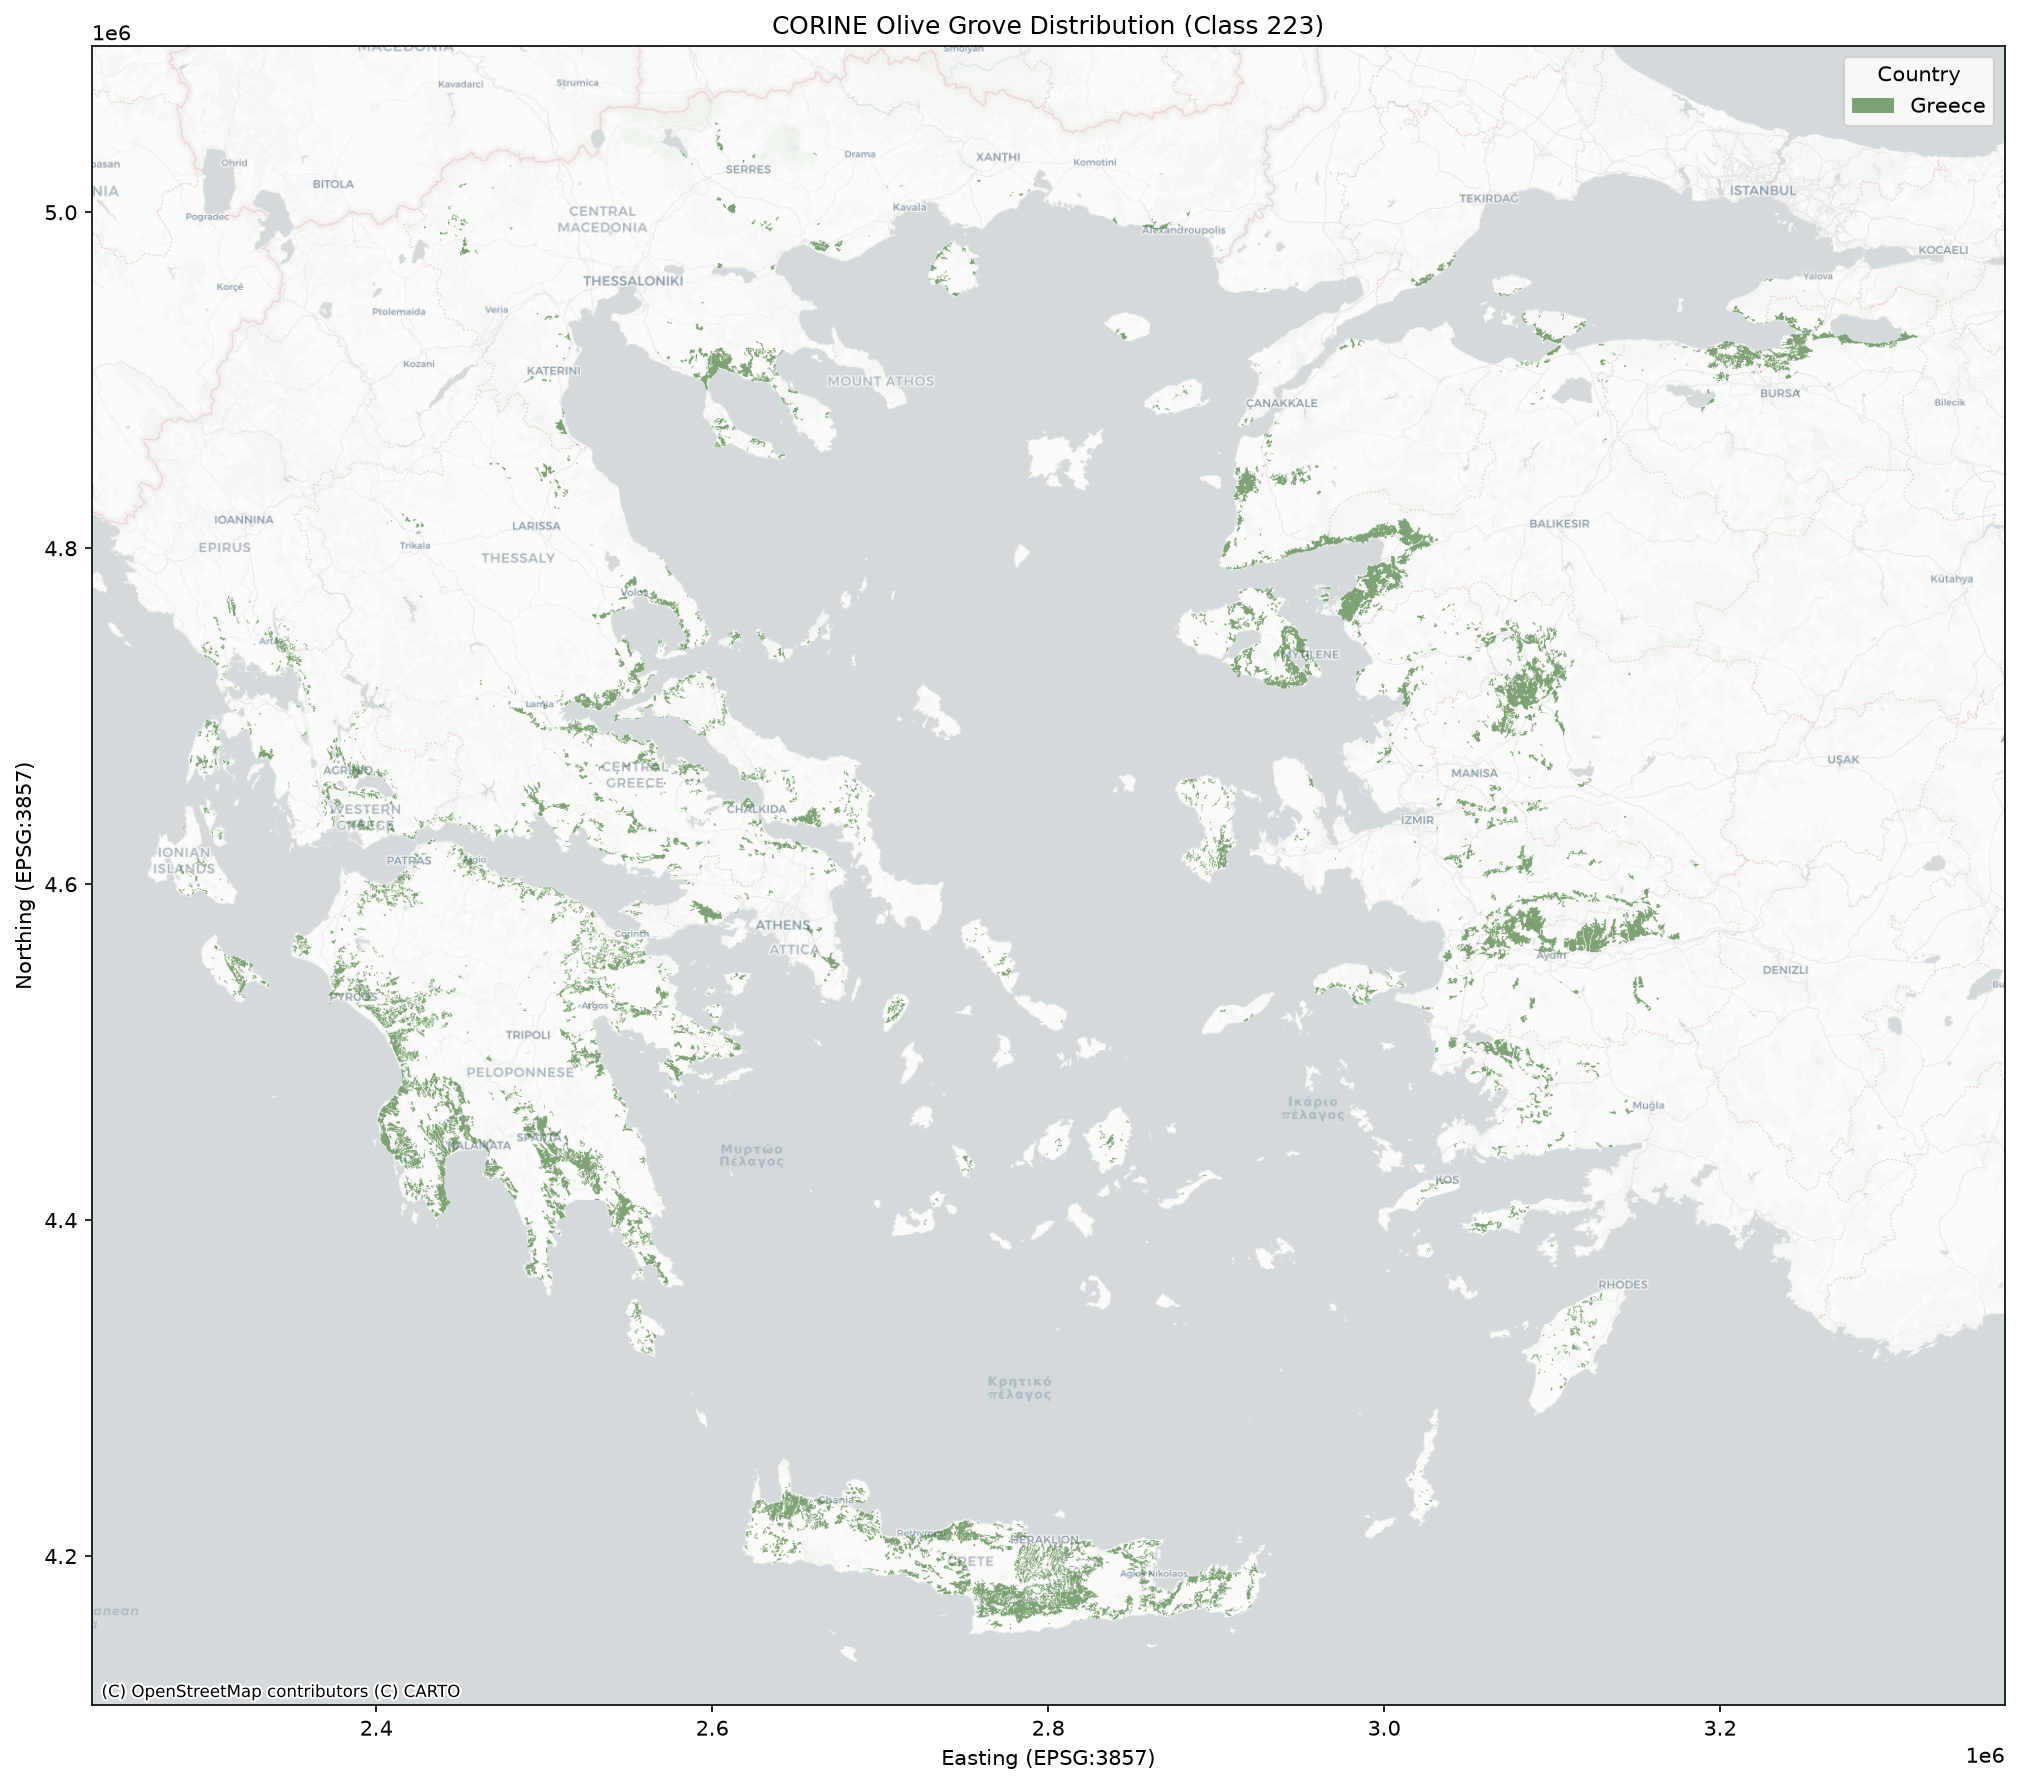

In [6]:
fig = plot_corine_olive_distribution(
    olive_by_country['GRC'],
    country_col='country',
    zoom=8,
    dpi=150,
    figsize=(14, 12),
)
plt.show()


---
## 3. Mediterranean comparison — all five countries

Left panel: olive groves coloured by country with latitude reference lines.  
Right panel: where in the 30–47 °N band does each country's olive belt sit?

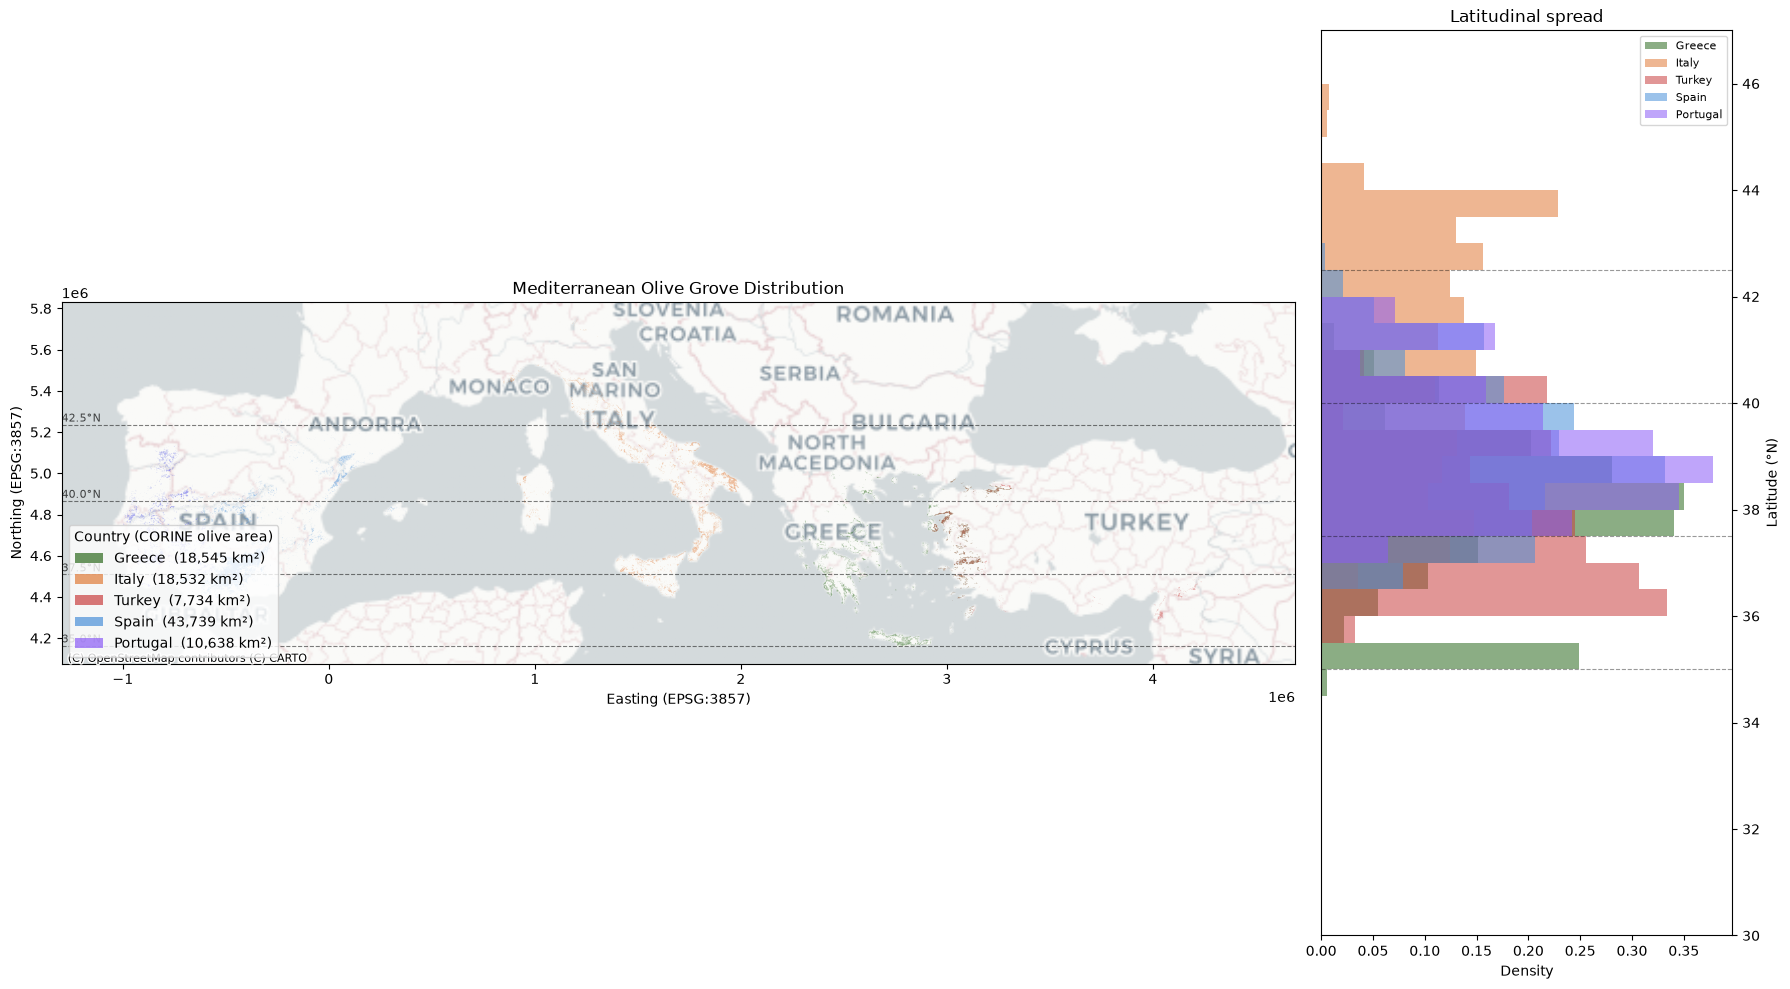

In [7]:
fig = plot_mediterranean_olive_comparison(
    olive_by_country,
    lat_lines=[35.0, 37.5, 40.0, 42.5],
)
plt.show()

---
## 4. Country statistics

In [8]:
rows = []
for iso3, gdf in olive_by_country.items():
    wgs = gdf.to_crs("EPSG:4326")
    web = gdf.to_crs("EPSG:3857")
    lats = wgs.geometry.centroid.y
    rows.append({
        "Country": _COUNTRY_NAMES.get(iso3, iso3),
        "Polygons": len(gdf),
        "Total area (km²)": web.geometry.area.sum() / 1e6,
        "Median polygon (ha)": web.geometry.area.median() / 1e4,
        "Lat min (°N)": lats.min(),
        "Lat median (°N)": lats.median(),
        "Lat max (°N)": lats.max(),
    })

(pd.DataFrame(rows)
   .set_index("Country")
   .sort_values("Total area (km²)", ascending=False)
   .round(1))

,Polygons,Total area (km²),Median polygon (ha),Lat min (°N),Lat median (°N),Lat max (°N)
Country,,,,,,
Spain,9427,43738.6,89.6,36.5,38.9,42.7
Greece,3076,18544.5,149.5,34.9,38.1,41.3
Italy,3782,18531.8,142.0,36.7,40.7,45.8
Portugal,3614,10637.5,95.0,37.1,38.9,41.8
Turkey,972,7734.2,161.6,35.5,37.7,40.8


---
## Summary

- Spain and Portugal extend olive cultivation furthest north (~43 °N in northern Iberia)
- Greece and Turkey concentrate 36–41 °N with an Aegean island cluster near Kythnos latitude (37.4 °N)
- Italy spans the widest range — Sicily (~37 °N) up to Liguria (~44 °N)
- The 37.5 °N reference line bisects Kythnos — compare against same-latitude olive regions in Puglia and western Turkey

Next: `02_feature_extraction.ipynb`